In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
!pip install xgboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

In [5]:
df = pd.read_csv("../data/data.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


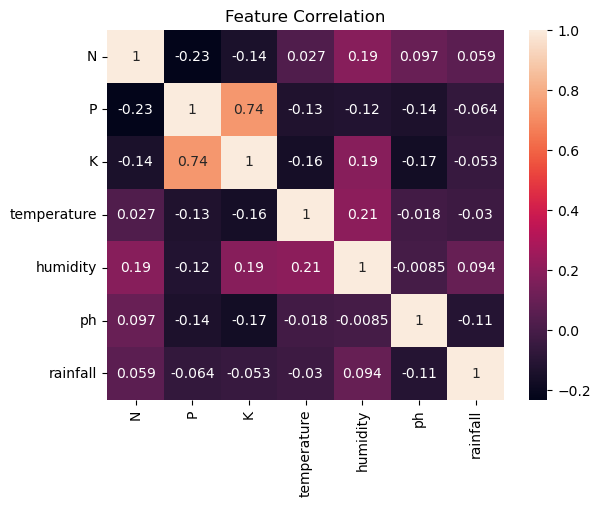

In [8]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation")

plt.savefig("../results/correlation.png")
plt.show()

In [9]:
X = df.drop("label", axis=1)
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
rf = RandomForestClassifier()
svm = SVC()
xgb = XGBClassifier(eval_metric='mlogloss')

rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
rf_acc = accuracy_score(y_test, rf.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

print("Random Forest:", rf_acc)
print("SVM:", svm_acc)
print("XGBoost:", xgb_acc)

Random Forest: 0.9954545454545455
SVM: 0.9681818181818181
XGBoost: 0.9840909090909091


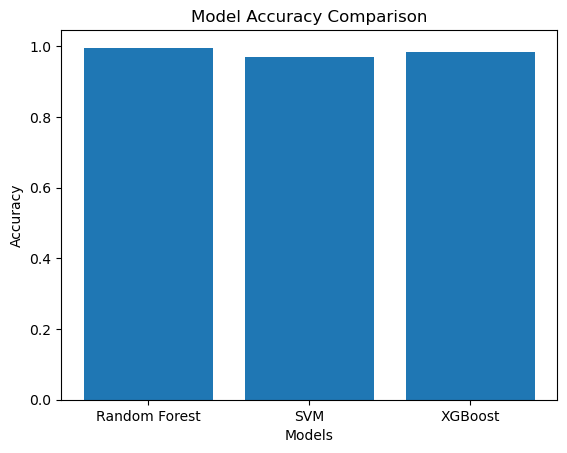

In [13]:
os.makedirs("../results", exist_ok=True)

models = ["Random Forest", "SVM", "XGBoost"]
scores = [rf_acc, svm_acc, xgb_acc]

plt.figure()
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.savefig("../results/accuracy.png")
plt.show()

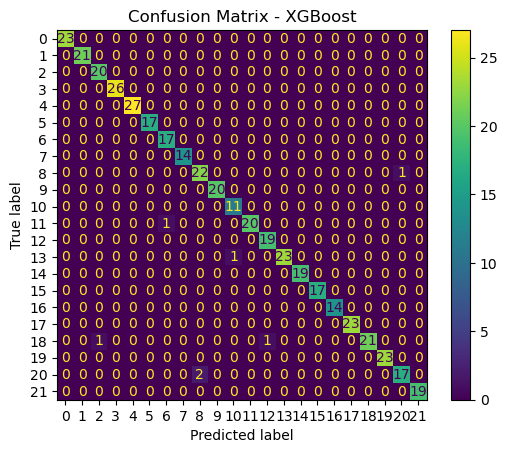

In [14]:
cm = confusion_matrix(y_test, xgb.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - XGBoost")
plt.savefig("../results/confusion_matrix.png")
plt.show()

In [15]:
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb, "../models/xgboost_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [16]:
sample = np.array([[90, 42, 43, 21, 82, 6.5, 200]])
sample_scaled = scaler.transform(sample)

prediction = xgb.predict(sample_scaled)
crop = le.inverse_transform(prediction)

print("Recommended Crop:", crop[0])

Recommended Crop: rice


C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
